# Figure 4: Active Turnover Modulates Multiphase Coexistence

Reproduces Figure 4A-B: phase counts over time and steady-state phase counts versus turnover rate.

In [1]:
import sys
sys.path.insert(0, '../../')

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

from jax_phase_separation import *
from jax_phase_separation.utils import build_params
from jax_phase_separation.analysis import analyse_snapshot
from jax_phase_separation.theory import n_phases_turnover_linear, n_phases_turnover_wigner

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/phase_separation


In [2]:
import sys, os, importlib
sys.path.insert(0, os.path.abspath('../..'))

import jax
import jax.numpy as jnp
import numpy as np
import matplotlib.pyplot as plt
import time

import jax_phase_separation.utils
import jax_phase_separation.solver
import jax_phase_separation.analysis
import jax_phase_separation.theory
importlib.reload(jax_phase_separation.utils)
importlib.reload(jax_phase_separation.solver)
importlib.reload(jax_phase_separation.analysis)
importlib.reload(jax_phase_separation.theory)

from jax_phase_separation.utils import (
    generate_chi_matrix, generate_initial_conditions, build_params,
)
from jax_phase_separation.solver import SimulationParams, simulate_with_snapshots
from jax_phase_separation.analysis import analyse_snapshot
from jax_phase_separation.theory import (
    n_phases_turnover_linear, n_phases_turnover_wigner,
)

print('JAX version:', jax.__version__)

JAX version: 0.10.0


## Parameters

N=20, sigma=5.4, equimolar, varying kon (and koff = kon*N/beta).

In [3]:
N_COM = 20
N_GRID = 48
SIGMA = 5.4
BETA = N_COM / (N_COM + 1.0)
DT = 5e-6
LMBDA = 0.01
KAPPA_MAG = 1.0
KAPPA_EFF = KAPPA_MAG * LMBDA
N_STEPS = 250_000
# N_STEPS = 2_000_000
SAVE_EVERY = 1_000
N_REPS = 5

KON_VALUES = [0.0, 0.1, 0.5, 1.0, 2.5, 5.0, 15.0, 50.0]

In [4]:
# JIT / XLA warmup: same N_COM, N_GRID, N_STEPS, SAVE_EVERY, kon, and progress_bar=False
# as the ensemble loop (jitted path). First call pays compile; later reps and other kon reuse it.
warm_key = jax.random.split(jax.random.PRNGKey(0), 3)
chi_w = generate_chi_matrix(N_COM, 0.0, SIGMA, warm_key[0])
c0_w = generate_initial_conditions(
    N_COM, N_GRID, beta=BETA, noise_strength=0.01, key=warm_key[1]
)
kon_warm = KON_VALUES[0]
params_w = build_params(chi_w, N_COM, beta=BETA, lmbda=LMBDA, dt=DT, kon=kon_warm)
t0 = time.time()
c_w, snaps_w = simulate_with_snapshots(
    c0_w, params_w, N_GRID, N_STEPS, save_every=SAVE_EVERY, progress_bar=False,
)
jax.block_until_ready(c_w)
print(f"JIT warmup done in {time.time() - t0:.1f}s (kon={kon_warm}; output discarded).")


JIT warmup done in 31.5s (kon=0.0; output discarded).


In [5]:
from tqdm import tqdm

master_key = jax.random.PRNGKey(99)

results_by_k = {}  # kon -> dict with 'n_phases_time', 'ss_phases'

for ki, kon in enumerate(tqdm(KON_VALUES, desc="kon values loop")):
    print(f'\nkon = {kon}')
    koff = kon * N_COM / BETA
    all_nph_time = []
    ss_phases_list = []

    rep_keys = jax.random.split(jax.random.fold_in(master_key, ki), N_REPS * 2)
    rep_keys = rep_keys.reshape(N_REPS, 2, -1)

    for rep in tqdm(range(N_REPS), desc=f"Reps for kon={kon}", leave=False):
        chi = generate_chi_matrix(N_COM, 0.0, SIGMA, rep_keys[rep, 0])
        c0 = generate_initial_conditions(N_COM, N_GRID, beta=BETA,
                                         noise_strength=0.01, key=rep_keys[rep, 1])
        params = build_params(chi, N_COM, beta=BETA, lmbda=LMBDA, dt=DT, kon=kon)

        t0 = time.time()
        c_final, snaps = simulate_with_snapshots(
            c0, params, N_GRID, N_STEPS, save_every=SAVE_EVERY, progress_bar=False,
        )
        elapsed = time.time() - t0

        nph_time = []
        for si in range(snaps.shape[0]):
            res = analyse_snapshot(np.array(snaps[si]))
            nph_time.append(res['n_phases'])
        all_nph_time.append(nph_time)

        ss_res = analyse_snapshot(np.array(c_final))
        ss_phases_list.append(ss_res['n_phases'])

        if (rep + 1) % 10 == 0:
            print(f'  rep {rep+1}/{N_REPS} done ({elapsed:.1f}s)')

    results_by_k[kon] = {
        'n_phases_time': np.array(all_nph_time),
        'ss_phases': np.array(ss_phases_list),
        'koff': koff,
    }
    print(f'  mean ss phases: {np.mean(ss_phases_list):.1f} +/- {np.std(ss_phases_list):.1f}')

print('\nDone.')

kon values loop:   0%|          | 0/8 [00:00<?, ?it/s]


kon = 0.0


kon values loop:  12%|█▎        | 1/8 [03:04<21:31, 184.48s/it]

  mean ss phases: 3.4 +/- 2.1

kon = 0.1


kon values loop:  25%|██▌       | 2/8 [06:10<18:32, 185.40s/it]

...

  mean ss phases: 2.2 +/- 0.7

kon = 15.0


kon values loop:  88%|████████▊ | 7/8 [21:28<03:02, 182.39s/it]

  mean ss phases: 1.4 +/- 0.5

kon = 50.0


kon values loop: 100%|██████████| 8/8 [24:25<00:00, 183.23s/it]

  mean ss phases: 1.0 +/- 0.0

Done.


## Figure 4A: N_phases vs time for different turnover rates

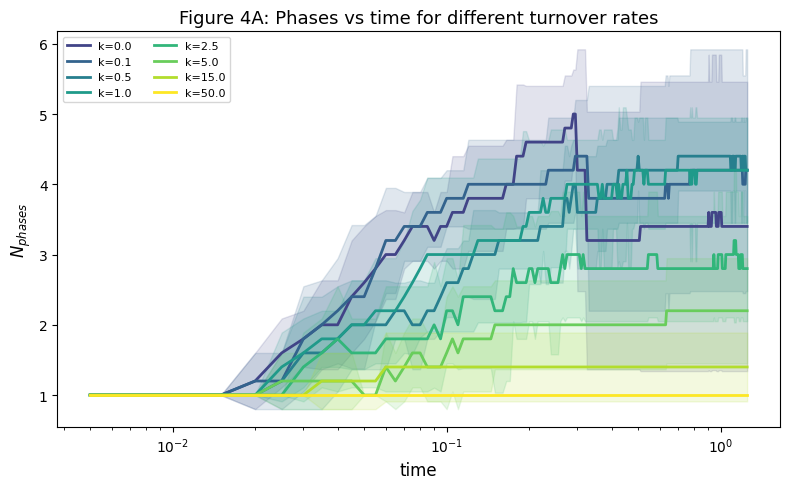

In [6]:
fig, ax = plt.subplots(figsize=(8, 5))
n_snaps = results_by_k[0.0]['n_phases_time'].shape[1]
t_axis = np.arange(1, n_snaps + 1) * SAVE_EVERY * DT

cmap = plt.get_cmap('viridis')
for ki, kon in enumerate(KON_VALUES):
    data = results_by_k[kon]['n_phases_time']
    mean = data.mean(axis=0)
    std = data.std(axis=0)
    color = cmap(0.2 + 0.8 * ki / (len(KON_VALUES) - 1))
    ax.fill_between(t_axis, mean - std, mean + std, alpha=0.15, color=color)
    ax.plot(t_axis, mean, color=color, lw=2, label=f'k={kon}')

ax.set_xscale('log')
ax.set_xlabel('time', fontsize=12)
ax.set_ylabel('$N_{phases}$', fontsize=12)
ax.set_title('Figure 4A: Phases vs time for different turnover rates', fontsize=13)
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

## Figure 4B: Steady-state phases vs koff with theory

KAPPA_EFF: 0.01


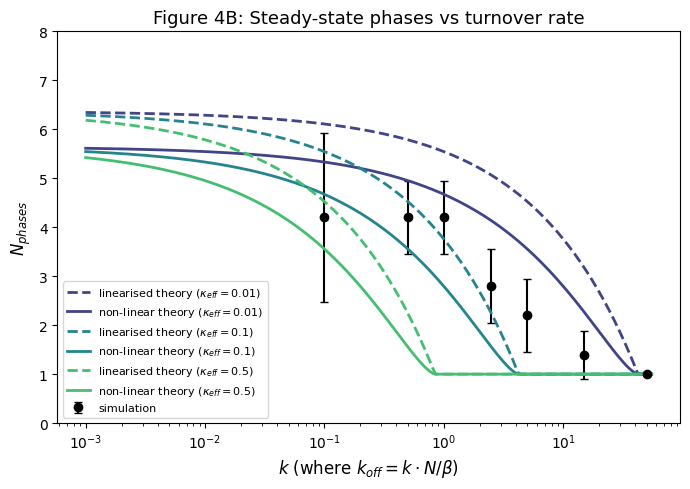

In [7]:
print('KAPPA_EFF:', KAPPA_EFF)

k_sim = np.array(KON_VALUES)
ss_mean = np.array([results_by_k[k]['ss_phases'].mean() for k in KON_VALUES])
ss_std = np.array([results_by_k[k]['ss_phases'].std() for k in KON_VALUES])

# Plot against kon, matching the paper notation.
k_theory = np.logspace(np.log10(k_sim.min() if k_sim.min() > 0 else 0.001), np.log10(k_sim.max() * 1.1), 200)
koff_theory = k_theory * N_COM / BETA

fig, ax = plt.subplots(figsize=(7, 5))
ax.errorbar(k_sim, ss_mean, yerr=ss_std, fmt='o', color='k',
            capsize=3, markersize=6, label='simulation')

# Theory predictions for several kappa_eff values.
kappa_eff_values = [0.01, 0.1, 0.5]
viridis_cmap = plt.get_cmap('viridis')
colors = [viridis_cmap(0.2 + 0.5 * i / (len(kappa_eff_values) - 1)) for i in range(len(kappa_eff_values))]

for i, kappa_eff in enumerate(kappa_eff_values):
    # Linear theory
    lin_pred = n_phases_turnover_linear(N_COM, SIGMA, koff_theory, kappa_eff=kappa_eff)
    ax.plot(
        k_theory, lin_pred,
        linestyle='--',
        color=colors[i],
        lw=2,
        label=fr'linearised theory ($\kappa_{{eff}}={kappa_eff}$)'
    )
    # Nonlinear theory
    nl_pred = n_phases_turnover_wigner(N_COM, SIGMA, koff_theory, kappa_eff=kappa_eff)
    ax.plot(
        k_theory, nl_pred,
        linestyle='-',
        color=colors[i],
        lw=2,
        label=fr'non-linear theory ($\kappa_{{eff}}={kappa_eff}$)'
    )

ax.set_xlabel(r'$k$ (where $k_{off} = k \cdot N / \beta$)', fontsize=12)
ax.set_ylabel('$N_{phases}$', fontsize=12)
ax.set_title('Figure 4B: Steady-state phases vs turnover rate', fontsize=13)
ax.set_xscale('log')
ax.set_ylim([0,8])
# ax.set_xlim([0.01,100])
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()